# **Air Quality Monitor Representativeness in the Contiguous United States**

#### **Objective:** Determine whether state and local governments site air monitors in areas that capture data that are representative of actual air quality. For this analysis, combine the cleaned EPA PM2.5 monitor dataset with the alternative PM2.5 estimates on a daily basis.

#### **Scope:** EPA monitor locations  in the contiguous United States in 2019 and daily PM2.5 estimates derived from an alternative air quality dataset during the same time period and frequency.

#### **Sources:**

| Num. | Title | Description | Source Link |
| :--- | :------------------------------ | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. | _daily_88101_2019_processed_v01.csv_ | This processed dataset contains PM2.5 monitor location for every day in the year 2019 within the contiguous United States. | NA <br><br> (Developed by this project in A_air_monitors_cleanup)
| 2. | USHAP\_PM2.5\_D1K\_2019\_V1.zip | Derived from research out of the Universities of Maryland and Iowa on 11/03/2025, this dataset contains 1\-kilometer resolution PM2.5 estimates in the contiguous United States for every day in the year 2019. The dataset was generated from big data \(e.g., ground\-based measurements, satellite remote sensing products, atmospheric reanalysis, and model simulations\) using artificial intelligence. The researchers show their estimates align well with physical measurements, with 0.82 cross\-validated coefficients of determination. | Paper: [https://www.thelancet.com/journals/lanplh/article/PIIS2542\-5196\(23\)00235\-8/fulltext](https://www.thelancet.com/journals/lanplh/article/PIIS2542-5196(23)00235-8/fulltext) <br> <br>  Data: <br> https://zenodo.org/records/7884640 |

#### **Conclusions:** The cleaned EPA dataset was combined with the Alternative PM2.5 dataset on a daily basis. 19,254 null values in the interim dataset, which are due to the alternative PM2.5 data not extending to Alaska, Hawaii or U.S. territories. Final dataset drops those areas.



#### General Methodology

##### Steps

1. Download Alternative Air Quality  Dataset
2. Load Libraries
3. Load Cleaned AQS Dataset and Plot Locations
4. Extract Alternative PM2.5 Values to Monitor Locations

##### Pseudocode

1. Load libraries I will likely need
2. Load AQS dataset: DF &lt;\- read.csv
3. Load the 364 Alternative PM2.5 datasets: DF &lt;\- read.netcdf
4. Use 364 dataset names to filter AQS data and then extract relevant values to monitor locations

Note I need to add our values to the air monitor dataset so we can assess how well they relate to physical air measurements. I take this step prior to using the data to identify hotspots for each county



#### Load Libraries



In [6]:
#Purpose of Cell Block: Load libraries I will likely need
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(readr))
suppressPackageStartupMessages(library(vroom))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(terra))
suppressPackageStartupMessages(library(naniar))

if (!require(dplyr)) install.packages("dplyr")
if (!require(dplyr)) install.packages("tidyr")
if (!require(readr)) install.packages("readr")
if (!require(vroom)) install.packages("vroom")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(stringr)) install.packages("stringr")
if (!require(stringr)) install.packages("terra")
if (!require(naniar)) install.packages("naniar")

library(dplyr)
library(tidyr)
library(readr)
library(vroom)
library(ggplot2)
library(stringr)
library(terra)
library(naniar)

#### Load Alternative PM2.5 Dataset


In [7]:
#Purpose of Cell Block: Locate and ready Alt. PM2.5 datasets 
setwd("/home/user/capstone/A_data")
altPM25_files <- list.files("C_raw_data/alternative_PM25_data", pattern = "\\.nc$", full.names = TRUE) #identify the number of alt. PM2.5 files in data folder
n_distinct(altPM25_files) #count alt. PM2.5 files

#Identify the relevant variable in the alternative dataset
altpm25_var <- names(rast(altPM25_files[1]))
altpm25_var

[1] 364

[1] "PM2.5"

#### Load Cleaned EPA AQS Dataset and Explore AQS and Alt PM2.5 Datasets

,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>
1,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-01,NA
2,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-02,NA
3,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-03,4.3
4,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-04,NA
5,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-05,NA
6,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-06,8.5


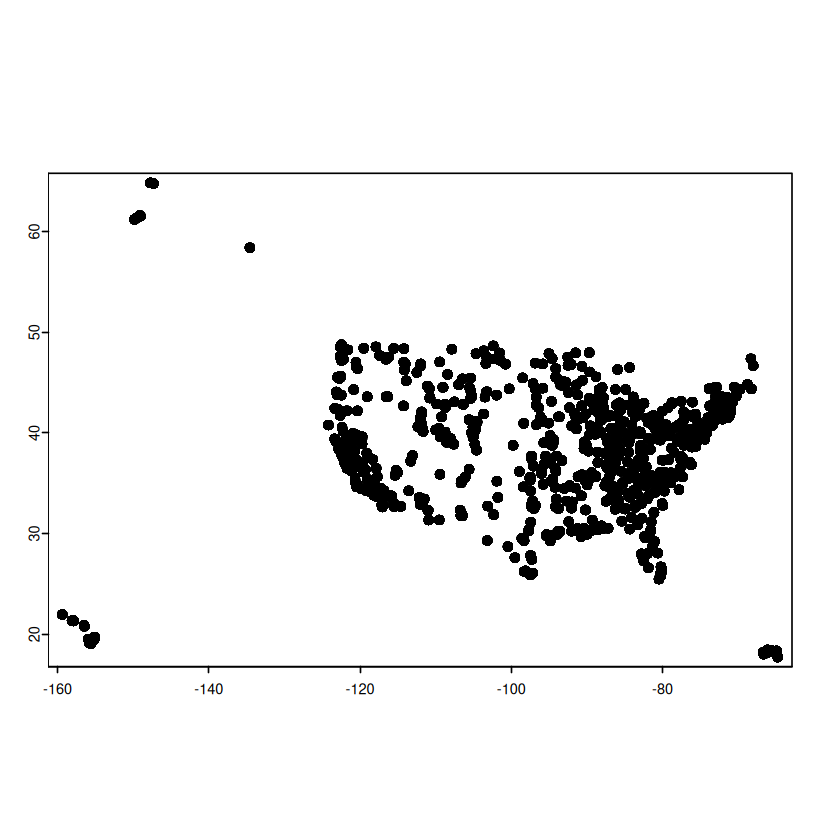

In [8]:
#Purpose of Cell Block: Load Processed AQM Dataset and Plot monitor locations
setwd("/home/user/capstone/A_data")
DF_aqs2019_processed <- read.csv("D_processed_data/air_monitors/daily_88101_2019_processed_v01.csv") %>%
    mutate('AQS_Site_ID' = str_pad(AQS_Site_ID, width = 9, pad = 0)) %>% #pad leading zero so state code always 9 char
    mutate(Date = as.Date(Date)) #converting date value from character to date

#Plotting monitor locations to confirm my dataset is working
monitor_table  <- DF_aqs2019_processed %>% 
    select(AQS_Site_ID, Longitude, Latitude)

monitor_points <- vect(monitor_table, geom = c("Longitude", "Latitude"), crs = "EPSG:4326")
plot(monitor_points)

head(DF_aqs2019_processed)

#### Extract Alt PM2.5 Values to PM2.5 Monitor Locations on Daily Basis

In [9]:
#Purpose of Cell Block: Grab Alt. PM2.5 value for each monitor location on each day

#Creating a function that converts the dates in the filenames into a string, which we can use to add our alternative PM2.5 variables to our daily monitor data
AltPM25_filename_date <- function(file_path) {
    file_name <- basename(file_path) #extract filename
    sDate <- regmatches(file_name, regexpr("[0-9]{8}", file_name)) #extract filenames' date
    as.Date(sDate, format = "%Y%m%d") #convert to date (storing it in sDate, which is a string)
}

#Create container to store results for each day
VEC_daily_results <- vector("list", length(altPM25_files))

i <- 0  # progress counter AND index into VEC_daily_results

#For each day of alternative data, grab the alternative date and use it to add alternative data to the associated day for each monitor
for (AltPM25_file in altPM25_files) {     
    AltDate <- AltPM25_filename_date(AltPM25_file) #See function above: Extracting date from filename 
    
    #Smaller helper to keep me updated on the for loop's progress (typical runtime is several minutes)
    i <- i + 1
    cat("\rProcessing", i, "of", length(altPM25_files),
        "| Date:", format(AltDate), "       ")
    flush.console()
    
    #Filter to only monitors on the date associated with our alternative PM2.5 dataset
    DF_monitors_on_date <- DF_aqs2019_processed %>%
        filter(Date == AltDate)
    
    #Prepare plot our filtered monitors 
    SPAC_points_on_date <- vect(DF_monitors_on_date %>% 
        select(AQS_Site_ID, Longitude, Latitude),
        geom = c("Longitude", "Latitude"),
        crs  = "EPSG:4326"
    )

    #Check total number of monitors
    DF_points_on_date <- as.data.frame(SPAC_points_on_date)
    
    total_points_on_date <- DF_points_on_date %>%
        summarise(total_sites = n_distinct(AQS_Site_ID))
    
    #Prepare plot for our alternative air quality data
    SPAC_alt_air_data_on_date <- rast(AltPM25_file)

    #Extract alternative PM2.5 value at monitor locations 
    DF_altPM25 <- extract(SPAC_alt_air_data_on_date, 
                          SPAC_points_on_date, 
                          ID = FALSE)
    
    varname <- names(DF_altPM25)[1] #Extract variable name from alternative dataset
    DF_monitors_on_date$Alt_PM25 <- DF_altPM25[[varname]]
    
    #Store day's results in the list
    VEC_daily_results[[i]] <- DF_monitors_on_date
}

#Combine ALL days into a single data frame
DF_AltPM25_all_days <- bind_rows(VEC_daily_results)

#Sanity check that extraction worked
print(head(DF_AltPM25_all_days))
print(names(DF_AltPM25_all_days))
print(summary(DF_AltPM25_all_days))

#Preserve output in processed data folder
write_csv(DF_AltPM25_all_days, "D_processed_data/alternative_PM25_data/alternative_PM25_data_processed_v01.csv")
print("Successfully exported dataset!")

Processing 1 of 364 | Date: 2019-01-01        

Processing 2 of 364 | Date: 2019-01-02        

Processing 3 of 364 | Date: 2019-01-03        

Processing 4 of 364 | Date: 2019-01-04        

Processing 5 of 364 | Date: 2019-01-05        

...

Processing 364 of 364 | Date: 2019-12-31        

  AQS_Site_ID Latitude Longitude
1   010030010 30.49748 -87.88026
2   010270001 33.28493 -85.80361
3   010331002 34.76262 -87.63810
4   010491003 34.28857 -85.96986
5   010550010 33.98821 -85.99256
6   010690003 31.22478 -85.39079
                                                   Address   State  County
1 FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE,  ALABAMA Alabama Baldwin
2                                          ASHLAND AIRPORT Alabama    Clay
3                                WILSON DAM RD AND 2ND ST. Alabama Colbert
4                      13112 HWY.68 , CROSSVILLE AL. 35962 Alabama  DeKalb
5                     314 COLLEGE DRIVE, GADSDEN, AL 35902 Alabama  Etowah
6              126 NORTH ST. ANDREWS STREET (CIVIC CENTER) Alabama Houston
           City       Date PM25_ugm3 Alt_PM25
1      Fairhope 2019-01-01        NA      7.2
2       Ashland 2019-01-01        NA      6.0
3 Muscle Shoals 2019-01-01        NA      5.0
4    Crossville 2019-01-01        NA      6.2
5       Gadsde

 [1] "AQS_Site_ID" "Latitude"    "Longitude"   "Address"     "State"      
 [6] "County"      "City"        "Date"        "PM25_ugm3"   "Alt_PM25"   


 AQS_Site_ID           Latitude       Longitude         Address         
 Length:362544      Min.   :17.71   Min.   :-159.37   Length:362544     
 Class :character   1st Qu.:35.12   1st Qu.:-109.11   Class :character  
 Mode  :character   Median :39.31   Median : -89.65   Mode  :character  
                    Mean   :38.43   Mean   : -94.95                     
                    3rd Qu.:41.73   3rd Qu.: -81.39                     
                    Max.   :64.85   Max.   : -64.78                     
                                                                        
    State              County              City                Date           
 Length:362544      Length:362544      Length:362544      Min.   :2019-01-01  
 Class :character   Class :character   Class :character   1st Qu.:2019-04-02  
 Mode  :character   Mode  :character   Mode  :character   Median :2019-07-02  
                                                          Mean   :2019-07-02  
                     

[1] "Successfully exported dataset!"


In [13]:
#Purpose of Cell Block: Assess NA values for Alt. PM25
setwd("/home/user/capstone/A_data")
DF_AltPM25_all_days <- read.csv("D_processed_data/alternative_PM25_data/alternative_PM25_data_processed_v01.csv")%>%
    mutate('AQS_Site_ID' = str_pad(AQS_Site_ID, width = 9, pad = 0)) %>% #pad leading zero so state code always 9 char
    mutate(Date = as.Date(Date)) #converting date value from character to date



head(DF_AltPM25_all_days)

#Visualize missingness
print("Variables with Missing Data (Count and Percent):")
DF_AltPM25_all_days %>%
    group_by(State) %>%
    summarise(
        missing_count  = n_miss(Alt_PM25),
        missing_percent = round(n_miss(Alt_PM25) / n() * 100, 4)
    )  %>%
  filter(missing_percent > 0) %>%
  arrange(desc(missing_percent))

#Conclusion: Drop Alaska, Hwaii, PR, and VI from the dataset. I will need to consider whether interpolation is approrpriate at a later date for the remaining list of states. Curiously the number missing for three states appears to be exactly or nearly 1 year, perhaps meaning one monitor in each area did not have their full year of rows generated in previous steps.

,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3,Alt_PM25
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>
1,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-01,NA,7.2
2,010270001,33.28493,-85.80361,ASHLAND AIRPORT,Alabama,Clay,Ashland,2019-01-01,NA,6.0
3,010331002,34.76262,-87.63810,WILSON DAM RD AND 2ND ST.,Alabama,Colbert,Muscle Shoals,2019-01-01,NA,5.0
4,010491003,34.28857,-85.96986,"13112 HWY.68 , CROSSVILLE AL. 35962",Alabama,DeKalb,Crossville,2019-01-01,NA,6.2
5,010550010,33.98821,-85.99256,"314 COLLEGE DRIVE, GADSDEN, AL 35902",Alabama,Etowah,Gadsden,2019-01-01,NA,7.9
6,010690003,31.22478,-85.39079,126 NORTH ST. ANDREWS STREET (CIVIC CENTER),Alabama,Houston,Dothan,2019-01-01,NA,10.4


[1] "Variables with Missing Data (Count and Percent):"


State,missing_count,missing_percent
<chr>,<int>,<dbl>
Alaska,3276,100.0000
Hawaii,5460,100.0000
Puerto Rico,2184,100.0000
Virgin Islands,728,100.0000
Wisconsin,365,5.0137
Washington,364,5.0000
Texas,365,2.5069
Wyoming,14,0.1748
Montana,8,0.1465


In [14]:
#Purpose of Cell Block: Drop administrative areas with 100 percent missing data

DF_AltPM25_all_days01 <- DF_AltPM25_all_days %>%
    filter(State != 'Alaska') %>%
    filter(State != 'Hawaii') %>%
    filter(State != 'Puerto Rico') %>%
    filter(State != 'Virgin Islands') 

print("Count of States Before Drop")
DF_AltPM25_all_days %>%
    summarise(count  = n_distinct(State))

print("Count of States After Drop")
DF_AltPM25_all_days01 %>%
    summarise(count  = n_distinct(State))

#Conclusion: Code correctly dropped the administrative areas with no alternative PM2.5 data

#Preserve output in processed data folder
write_csv(DF_AltPM25_all_days01, "D_processed_data/alternative_PM25_data/alternative_PM25_data_processed_v02.csv")
print("Successfully exported dataset!")

[1] "Count of States Before Drop"


count
<int>
53


[1] "Count of States After Drop"


count
<int>
49


[1] "Successfully exported dataset!"
